In [3]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In this notebook, we will implement a solver for the l1 regularized linear regression (lasso).

The idea is to use `cvxpy` to define an optimization problem, which can be solved with one of the provided solvers (e.g., `OSQP`).


Note: this demonstration is a bit more difficult than the others in this session, so it is given. If you like a challenge, delete and rewrite it youself :)

In [4]:
def solve_l1(A: np.ndarray, b: np.ndarray, eps: float):

    # Get the number of variables we have
    n = A.shape[1]

    # build the QP
    # The first term comes from the Hessian of the QP part of the problem.
    # We introduce auxiliary variables `mu` to make the absolute value 'workable'.
    # the variable we are optimizing is the concatenation of the coefficients and mu
    # Note that mu does not contribute to the quadratic term
    H_top   = 2 * A.T @ A          # n×n
    H = np.block([[H_top,           np.zeros((n, n))],
                  [np.zeros((n, n)), np.zeros((n, n))]])        # 2n × 2n

    # Linear term
    # We concatenate the linear term from the least-squares term and epsilon * ones(n), so that their sum is epsilon * sum(mu).
    # This is useful because as a constrain we will force mu to be >= |x|
    f = np.concatenate([-2 * A.T @ b, eps * np.ones(n)])        # 2n vector

    # Inequality constraints: μ ≥ x  and  μ ≥ –x
    # taken together, they guarantee that mu >= |x|. The optimizer will force each mu to be exactly the corresponding |x|
    Aineq = np.block([[np.eye(n), -np.eye(n)],
                      [-np.eye(n), -np.eye(n)]])                # 2n × 2n
    bineq = np.zeros(2 * n)

    # CVXPY problem 
    # Now, we create a variable of size 2*n
    z = cp.Variable(2 * n)

    # then, create the objective function (using convenient notation cp.quadform)
    objective = (1/2) * cp.quad_form(z, H) + f.T @ z

    # define the constraints
    constraints = [Aineq @ z <= bineq]

    # and create the problem
    prob = cp.Problem(cp.Minimize(objective), constraints)

    # Solve the problem using a QP solver
    prob.solve(solver=cp.OSQP, verbose=False)

    return z.value[:n]   # The first n entries are the coefficients x

Das ursprüngliche Optimierungsproblem der **L1-regularisierten linearen Regression** lautet:

$$
\min_{x \in \mathbb{R}^n} \; \|A x - b\|_2^2 + \varepsilon \|x\|_1
$$

Da der Betrag $|x_i|$ nicht differenzierbar ist, führen wir Hilfsvariablen 
$\mu_i \ge |x_i|$ ein und schreiben das Problem äquivalent als:

$$
\begin{aligned}
\min_{x, \mu \in \mathbb{R}^n} \quad 
    & \|A x - b\|_2^2 + \varepsilon \sum_{i=1}^n \mu_i \\[4pt]
\text{s.t.} \quad 
    & \mu_i \ge x_i, \quad i = 1, \dots, n, \\[2pt]
    & \mu_i \ge -x_i, \quad i = 1, \dots, n.
\end{aligned}
$$

Im Optimum gilt $\mu_i = |x_i|$, und das Problem wird zu einer 
**quadratischen Optimierungsaufgabe (QP)** mit linearen Ungleichungen.


In [5]:
X,y = make_regression(
    n_samples=1000,
    n_features=50,
    n_informative=2,
    shuffle=False
)


theta_l1 = solve_l1(X, y, eps=1)

Note how sharp the coefficients are

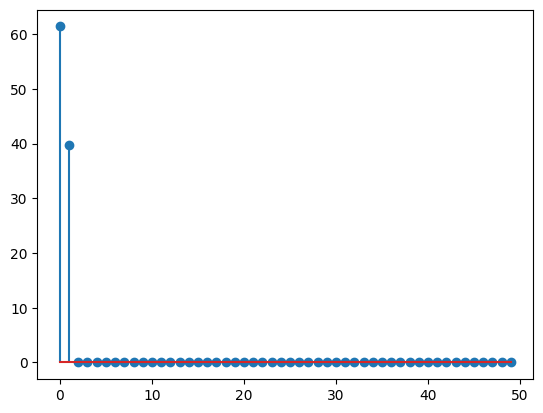

In [6]:
plt.stem(theta_l1)
plt.show()